# Lesson: nanoaod to csv

In this lesson you will learn how to:
* fetch data from the CERN Open Data Portal
* open the data and see what they contain
* make simple selections
* make simple plots
* export the selected events to a csv (comma-separated-variable) file

If you are running this notebook in Google Colab run the following cell:

Before we do anything, let's import the required libraries:

In [ ]:
!pip install -r https://raw.githubusercontent.com/cms-opendata-workshop/workshop2026-lesson-nanoaod2csv/main/requirements.txt

In [1]:
import os
import uproot
import awkward as ak
import pandas as pd

## 1. Fetch data

Let's get data from the CERN Open Data Portal, in particular, a DoubleMuon dataset from 2016 in NANOAOD format:

[/DoubleMuon/Run2016H-UL2016_MiniAODv2_NanoAODv9-v1/NANOAOD](https://opendata.cern.ch/record/30555)

We will use the `cernopendata-client` to see what files are available and fetch one.

In [2]:
!cernopendata-client --help

Usage: cernopendata-client [OPTIONS] COMMAND [ARGS]...

  Command-line client for interacting with CERN Open Data portal.

Options:
  --help  Show this message and exit.

Commands:
  download-files      Download data files belonging to a record.
  get-file-locations  Get a list of data file locations of a record.
  get-metadata        Get metadata content of a record.
  list-directory      List contents of a EOSPUBLIC Open Data directory.
  verify-files        Verify downloaded data file integrity.
  version             Return cernopendata-client version.


In [3]:
!cernopendata-client get-file-locations --recid 30555 --verbose

http://opendata.cern.ch/eos/opendata/cms/Run2016H/DoubleMuon/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/2510000/127C2975-1B1C-A046-AABF-62B77E757A86.root	2016828178	adler32:eff37065
http://opendata.cern.ch/eos/opendata/cms/Run2016H/DoubleMuon/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/2510000/183BFB78-7B5E-734F-BBF5-174A73020F89.root	2010323460	adler32:78b69eb2
http://opendata.cern.ch/eos/opendata/cms/Run2016H/DoubleMuon/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/2510000/790F8A75-8256-3B46-8209-850DE0BE3C77.root	1643033529	adler32:74252daa
http://opendata.cern.ch/eos/opendata/cms/Run2016H/DoubleMuon/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/2510000/7F53D1DE-439E-AD48-871E-D3458DABA798.root	1913547715	adler32:52ca2e8a
http://opendata.cern.ch/eos/opendata/cms/Run2016H/DoubleMuon/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/2510000/8A696857-C147-B04A-905A-F85FB76EDA23.root	2448295089	adler32:e3c02800
http://opendata.cern.ch/eos/opendata/cms/Run2016H/DoubleMuon/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/2510000/8B253755

In [4]:
file_name = './30555/EEB2FE3F-7CF3-BF4A-9F70-3F89FACE698E.root'

if not (os.path.isfile(f'{file_name}')):
 !cernopendata-client download-files --recid 30555 --filter-range 20-20

## 2. Open the data and inspect

In [5]:
infile = uproot.open(file_name)

keys = infile.keys()
print(keys)

['tag;1', 'Events;1', 'LuminosityBlocks;1', 'Runs;1', 'MetaData;1', 'ParameterSets;1']


In [6]:
events = infile['Events']
events.show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
run                  | uint32_t                 | AsDtype('>u4')
luminosityBlock      | uint32_t                 | AsDtype('>u4')
event                | uint64_t                 | AsDtype('>u8')
nboostedTau          | uint32_t                 | AsDtype('>u4')
boostedTau_charge... | float[]                  | AsJagged(AsDtype('>f4'))
boostedTau_eta       | float[]                  | AsJagged(AsDtype('>f4'))
boostedTau_leadTk... | float[]                  | AsJagged(AsDtype('>f4'))
boostedTau_leadTk... | float[]                  | AsJagged(AsDtype('>f4'))
boostedTau_leadTk... | float[]                  | AsJagged(AsDtype('>f4'))
boostedTau_mass      | float[]                  | AsJagged(AsDtype('>f4'))
boostedTau_neutra... | float[]                  | AsJagged(AsDtype('>f4'))
boostedTau_phi       | float[]                  | AsJ

What does all this mean? Recall that thankfully in the dataset record there is a list of file variables (with explanations) under `Dataset semantics`. The link is [here](https://opendata.cern.ch/eos/opendata/cms/dataset-semantics/NanoAOD/30555/DoubleMuon_doc.html).

We will next reduce down to only variables related to Muon objects and open them as `awkward` arrays into

In [7]:
filter_name='/(Muon_|nMuon)/'
muon_info = events.arrays(filter_name=filter_name, library='ak')

In [8]:
muon_info

<Array [{nMuon: 2, Muon_dxy: [...], ...}, ...] type='285647 * {nMuon: uint3...'>

## 3. Simple selections

Next we'll make some simple selections on these events. For now, we will only require that events have precisely two global muons.

In [9]:
nmuon_selection = (muon_info['nMuon'] == 2)

In [10]:
print(len(muon_info))
muon_info = muon_info[nmuon_selection]
print(len(muon_info))

285647
150096


In [11]:
global_muon_selection = ak.all(muon_info['Muon_isGlobal'], axis=1)

In [12]:
print(len(muon_info))
muon_info = muon_info[global_muon_selection]
print(len(muon_info))

150096
131528


## 4. Simple plots (after exporting to a Pandas DataFrame)

In [13]:
d = {
    'pt1': muon_info['Muon_pt'][:,0],
    'eta1': muon_info['Muon_eta'][:,0],
    'phi1': muon_info['Muon_phi'][:,0],
    'charge1': muon_info['Muon_charge'][:,0],
    'pt2': muon_info['Muon_pt'][:,1],
    'eta2': muon_info['Muon_eta'][:,1],
    'phi2': muon_info['Muon_phi'][:,1],
    'charge2': muon_info['Muon_charge'][:,1],
}

In [14]:
df = pd.DataFrame(d)
df

,pt1,eta1,phi1,charge1,pt2,eta2,phi2,charge2
0,28.097813,0.457153,0.948120,-1,12.121260,-0.934082,-3.017090,1
1,46.035191,-0.944824,-1.505371,-1,20.686039,0.876465,1.854004,1
2,23.112928,0.086716,0.696045,1,9.375922,0.431152,-2.932129,1
3,41.076912,-1.173340,1.110596,1,38.454723,-2.439941,-2.111328,-1
4,8.039757,-1.040283,0.992188,-1,5.669646,-0.035530,-2.907715,-1
...,...,...,...,...,...,...,...,...
131523,8.663555,-1.200928,0.053383,1,4.196473,-1.231201,-0.164398,-1
131524,49.347862,0.879272,-2.394043,-1,9.715683,1.181885,-2.741699,1
131525,36.811653,-1.855225,-0.537964,-1,3.625861,1.607422,-2.921875,1
131526,187.041214,0.147217,-2.648926,-1,50.155972,-0.737061,-2.461426,1


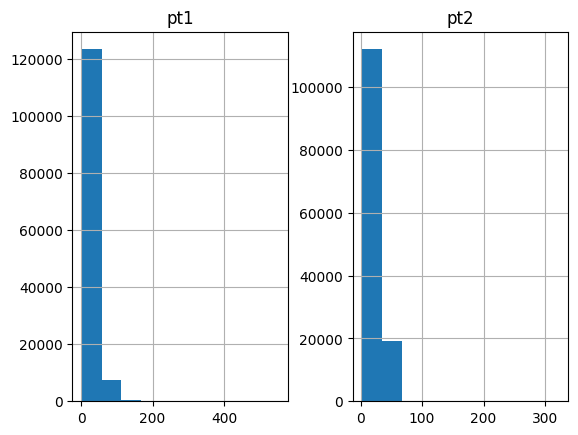

In [15]:
pt_hist = df.hist(['pt1', 'pt2'])

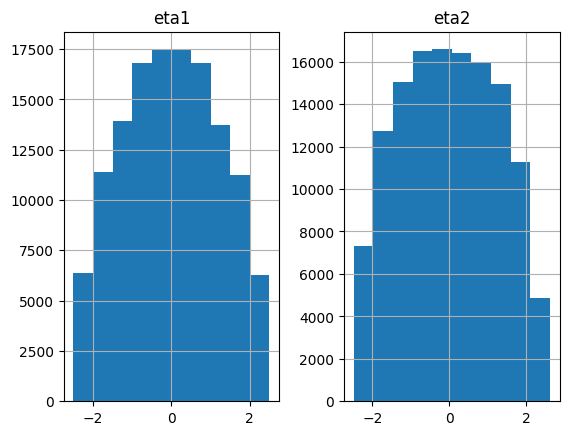

In [16]:
eta_hist = df.hist(['eta1', 'eta2'])

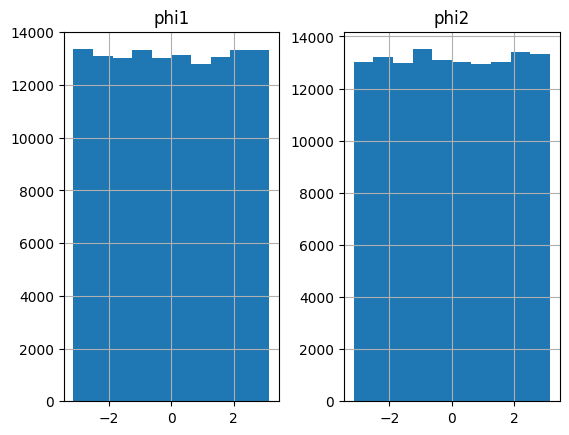

In [17]:
phi_hist = df.hist(['phi1', 'phi2'])

## 5. Export to a csv file

Before we export to the csv files we can also make some simple selections using Pandas. For example, let's select only those events where the muons are oppositely-charged:

In [18]:
oppcharge_selection = (df['charge1']*df['charge2'] == -1)
print(oppcharge_selection)

0          True
1          True
2         False
3          True
4         False
          ...  
131523     True
131524     True
131525     True
131526     True
131527     True
Length: 131528, dtype: bool


In [19]:
df[oppcharge_selection].to_csv(
    'DoubleMuonRun2016H.csv',
    index=False
)